This project automatically extracts structured information
from a photo of a receipt.

Here is the pipeline:
1) Preprocession of the photo(resize, blur, threshold)
2) Dilatation of preprocessed image
3) Get a countour from dilatated image which is simple because the image is already very simplified by preprocessing and dilataion
4) Crop the image using gotten contour
5) Get the text using pytesseract
6) Get a structured-json like information using Gemini
7) Save gotten information in an old json file or create a new one if the last one doesn't exist

In [1]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
import pytesseract
from google import genai
import json
import re
from pathlib import Path
pytesseract.pytesseract.tesseract_cmd = (r"..\Tesseract-OCR\tesseract.exe") # put location of pytesseract on your computer

API_KEY = "..." # put your gemini api-key here
client = genai.Client(api_key=API_KEY)

In [2]:
IMAGE_WIDTH = 800

GAUSSIAN_KERNEL = (5,5)

DILATION_KERNEL = 5

DILATION_ITERATIONS = 2

OUTPUT_JSON = "receipts.json" # put your json file

In [3]:
receipt_path = "receipt.jpg" # put the path to your receipt
originalImage = cv2.imread(receipt_path)
if originalImage is None:
    raise FileNotFoundError(path)
originalImage = cv2.cvtColor(originalImage, cv2.COLOR_BGR2GRAY)

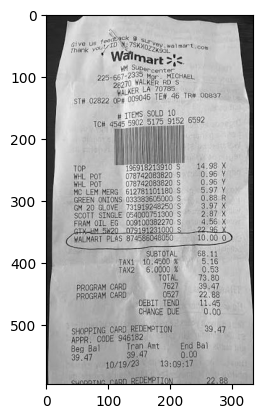

In [4]:
plt.imshow(originalImage, 'gray')

In [5]:
def resize(img, new_width):
    """Resize an image saving proportions"""
    h, w = img.shape[:2]
    new_height = int(h * new_width / w)
    return cv2.resize(img, (new_width, new_height))

def check_corners(img):
    """Check if the corners are not white. If so, inverse the colors"""
    h, w = img.shape[:2]
    corners = [img[0,0], img[0,w-1], img[h-1,0], img[h-1,w-1]]
    if np.mean(corners) > 127:
        img = cv2.bitwise_not(img)
    return img

def preprocess_image(img):
    """Preprocessing pipeline"""
    img_blured = cv2.GaussianBlur(img, GAUSSIAN_KERNEL, 0)
    _, thresh = cv2.threshold(img_blured, 0, 255, cv2.THRESH_BINARY + cv2.THRESH_OTSU) # Adaptive threshold compensates for uneven lighting                                                                        # and improves OCR accuracy.
    img_checked = check_corners(thresh)
    return img_checked

In [6]:
def dilate(img,  nbiterations, kernel_size):
    """Connect nearby white regions so the receipt becomes a single connected contour"""
    kernel = np.ones((kernel_size,kernel_size), np.uint8)
    dilated = cv2.dilate(img, kernel, iterations=nbiterations)
    return dilated

def get_contours(img):
    """
    Find the largest external contour in the image and
    approximate it with a polygon.

    Returns:
        tuple: The largest contour and its polygon approximation.

    Raises:
        ValueError: If no contours are found.
    """
    contours, _ = cv2.findContours(
    img,
    cv2.RETR_EXTERNAL,
    cv2.CHAIN_APPROX_SIMPLE
    )
    if len(contours) == 0:
        raise ValueError("No receipt detected.")
        
    largest = max(contours, key=cv2.contourArea)
    peri = cv2.arcLength(largest, True)
    
    approx = cv2.approxPolyDP(
        largest,
        0.02 * peri,
        True)
    return largest, approx

In [7]:
def perspective_transform(contour, img):
    """
    Apply a perspective transform to obtain a top-down
    view of the receipt.

    Args:
        contour: A four-point contour approximating the receipt.
        img: The original input image.

    Returns:
        The warped (cropped and rectified) receipt image.
    """
    input_pts = contour.reshape(4, 2).astype(np.float32) # order_points(contour.reshape(4, 2).astype(np.float32))
    
    width1 = np.linalg.norm(input_pts[0] - input_pts[3])
    width2 = np.linalg.norm(input_pts[1] - input_pts[2])
    maxWidth = int(max(width1, width2))
    
    height1 = np.linalg.norm(input_pts[0] - input_pts[1])
    height2 = np.linalg.norm(input_pts[2] - input_pts[3])
    maxHeight = int(max(height1, height2))
    
    output_pts = np.float32([
        [0, 0],
        [0, maxHeight - 1],
        [maxWidth - 1, maxHeight - 1],
        [maxWidth - 1, 0]
    ])

    warped = cv2.warpPerspective(
        img,
        cv2.getPerspectiveTransform(input_pts, output_pts),
        (maxWidth, maxHeight),
        flags=cv2.INTER_LINEAR
    )
    return warped

In [8]:
def extract_text(img) -> str:
    """Extract text from the receipt image using Tesseract OCR"""
    scan = cv2.adaptiveThreshold( # make an adaptive threshold to simplify getting the text from the image
        img,
        255,
        cv2.ADAPTIVE_THRESH_GAUSSIAN_C,
        cv2.THRESH_BINARY,
        21,
        15
    )
    text = pytesseract.image_to_string(scan)
    return text

In [9]:
def extract_receipt_information(text) -> dict:
    """
    Extract structured receipt information from OCR text using Gemini.

    Args:
        text (str): Raw OCR text extracted from a receipt.

    Returns:
        dict: Parsed receipt data:
            {
            "store": str,
            "date": str,
            "currency": str,
            "items": list,
            "tax": float,
            "total": float
            }

    Raises:
        ValueError: If Gemini does not return valid JSON.
    """
    
    prompt = f"""
    You are an expert receipt parser.
    
    Extract the following information:
    
    - Store name
    - Purchase date
    - Currency
    - Items (name and price)
    - Tax
    - Total
    
    Return ONLY valid JSON.
    Do not use Markdown.
    Do not wrap the JSON in ```json.
    
    Receipt:
    
    {text}
    """
    
    response = client.models.generate_content(
        model="models/gemini-3.6-flash",
        contents=prompt
    )

    response = response.text.strip() # Parse Gemini response
    try:
        receipt = json.loads(response)
    except json.JSONDecodeError:
        raise ValueError("Gemini returned invalid JSON.")

    return receipt

In [10]:
def save_json(json_file, receipt):
    """
    Save receipt information into a JSON file.
    """
    path = Path(json_file)
    
    if path.exists():
        with open(json_file, "r") as f:
            # data = json.load(f)
            try:
                with path.open("r", encoding="utf-8") as f:
                    data = json.load(f)
            except json.JSONDecodeError:
                data = []    
    else:
        data = []
        
    data.append(receipt)
    
    with path.open("w", encoding="utf-8") as f:
        json.dump(data, f, indent=4, ensure_ascii=False)

In [11]:
def draw_results(img, img_preprocessed, img_dilated, img_warped, largest_contour, approx_polygon):
    """
    Display intermediate results of receipt contour detection.
    """
    raw_result = img.copy()
    approx_result = img.copy()
    cv2.drawContours(raw_result, [largest_contour], -1, (255,0,0), 3)
    cv2.drawContours(approx_result, [approx_polygon], -1, (0,255,0), 3)
    
    fig, axs = plt.subplots(1, 6, figsize=(20,5))
    axs[0].imshow(img)
    axs[0].set_title('Original Image')
    axs[1].imshow(img_preprocessed, 'gray')
    axs[1].set_title('Blurred + Thresholded Image')
    axs[2].imshow(img_dilated, cmap='gray')
    axs[2].set_title('Dilated Image')
    axs[3].imshow(raw_result,)
    axs[3].set_title('Largest Raw Contour')
    axs[4].imshow(approx_result, )
    axs[4].set_title('Approximated Contour')
    axs[5].imshow(img_warped, cmap='gray')
    axs[5].set_title('Warped Image')
    plt.show()

In [12]:
def scan_receipt(image_path, visualize=False) -> dict:
    """
    Execute the complete receipt scanning pipeline.
    """
    image = cv2.imread(image_path)
    if image is None:
        raise FileNotFoundError(f'Could not load image: {image_path}')

    image = resize(image, IMAGE_WIDTH)

    image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

    gray = cv2.cvtColor(image, cv2.COLOR_RGB2GRAY)
    
    preprocessed = preprocess_image(gray)

    img_dilated = dilate(preprocessed, DILATION_ITERATIONS, DILATION_KERNEL)

    largest, approx = get_contours(img_dilated)

    warped = perspective_transform(approx, gray)

    text = extract_text(warped)
    
    receipt = extract_receipt_information(text)

    save_json(OUTPUT_JSON, receipt)
    if visualize:
        draw_results(image, preprocessed, img_dilated, warped, largest, approx)
    return receipt

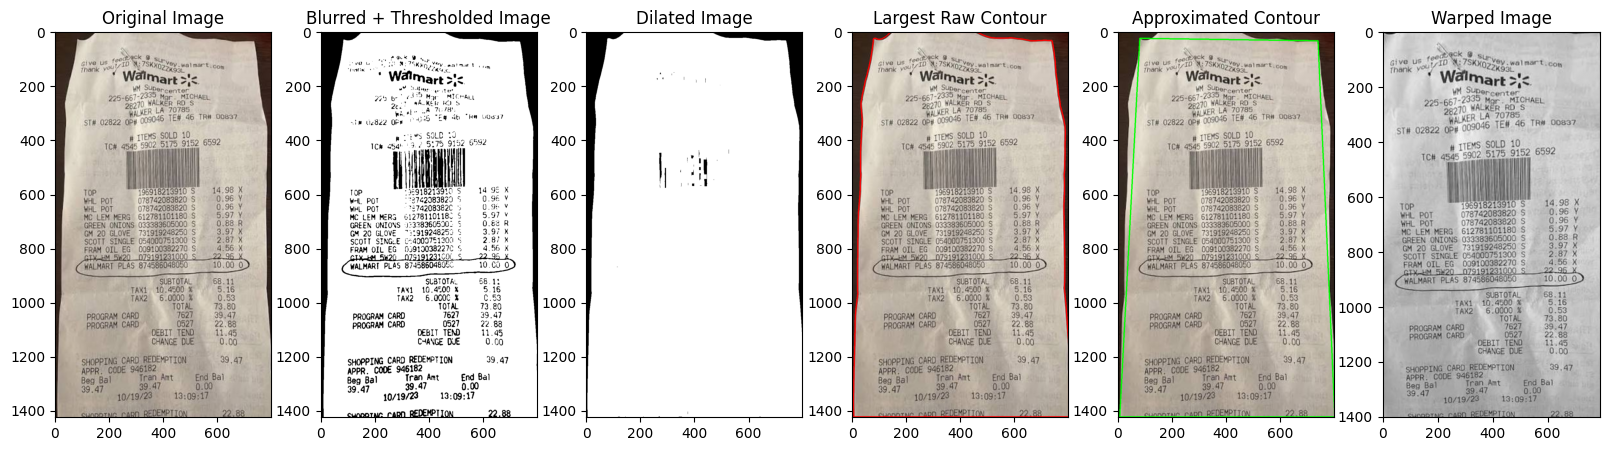

{'store_name': 'Walmart', 'purchase_date': '2023-10-19', 'currency': 'USD', 'items': [{'name': 'Mt', 'price': 14.98}, {'name': 'WHL POT', 'price': 0.96}, {'name': 'WHL POT', 'price': 0.96}, {'name': 'MC LEM MERG', 'price': 5.97}, {'name': 'GREEN ONIONS', 'price': 0.88}, {'name': 'GM 20 GLOVE', 'price': 3.97}, {'name': 'SCOTT SINGLE', 'price': 2.87}, {'name': 'FRAM OTL EG', 'price': 4.56}, {'name': 'WALMART PLAS', 'price': -10.0}], 'tax': 5.69, 'total': 73.8}


In [13]:
result = scan_receipt(receipt_path, True)
print(result)